In [1]:
import pandas as pd
df=pd.read_csv("retail_sales_dataset.csv")
print(df.head())

  transaction_id transaction_date customer_id customer_gender  \
0       T0000001       2024-04-24     C000820           Other   
1       T0000002       2025-07-12     C002849           Other   
2       T0000003       2025-06-01     C019727            Male   
3       T0000004       2025-08-26     C009116            Male   
4       T0000005       2024-12-10     C003350            Male   

  customer_age_group customer_segment product_id   product_name  category  \
0              35-44        Returning      P1082      Dumbbells    Sports   
1              45-54              New      P1087  Running Shoes    Sports   
2                55+        Returning      P1030       Sneakers  Clothing   
3              25-34              VIP      P1058      Sunscreen    Beauty   
4              45-54              New      P1028       Sneakers  Clothing   

     brand  quantity  unit_price  discount_pct  sales_amount payment_method  \
0  Brand 1         2      313.53            20        501.65     De

In [2]:
%pip install matplotlib seaborn scikit-learn prophet statsmodels -q

Note: you may need to restart the kernel to use updated packages.


# Time Series Sales Forecasting

This project forecasts future retail sales using historical data with multiple models (ARIMA, Prophet, LSTM).

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Data Preparation & Visualization

Time series length: 730 days
Date range: 2024-01-01 00:00:00 to 2025-12-30 00:00:00

Daily Sales Statistics:
count      730.000000
mean     62132.951301
std       6766.212227
min      39016.240000
25%      57340.492500
50%      61765.400000
75%      66150.300000
max      85801.190000
Name: sales_amount, dtype: float64


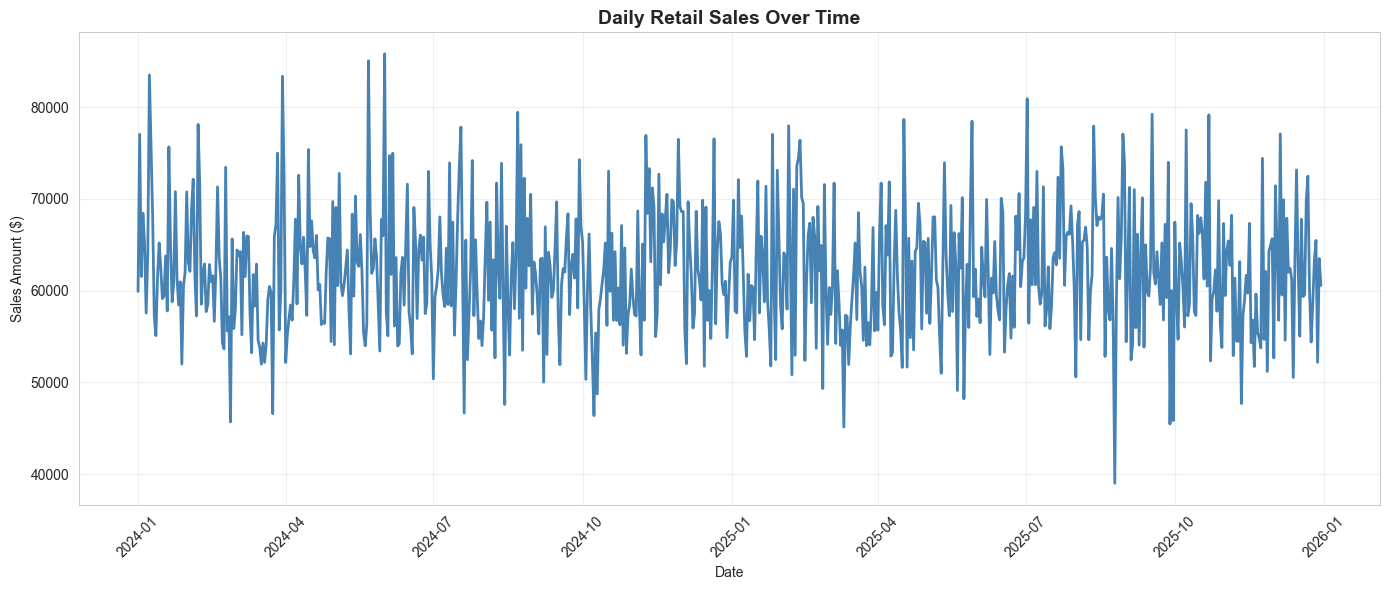


Missing dates: 0


In [4]:
# Convert transaction_date to datetime and aggregate daily sales
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
daily_sales = df.groupby('transaction_date')['sales_amount'].sum().sort_index()

print(f"Time series length: {len(daily_sales)} days")
print(f"Date range: {daily_sales.index.min()} to {daily_sales.index.max()}")
print(f"\nDaily Sales Statistics:")
print(daily_sales.describe())

# Visualize historical sales
plt.figure(figsize=(14, 6))
plt.plot(daily_sales.index, daily_sales.values, linewidth=2, color='steelblue')
plt.title('Daily Retail Sales Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales Amount ($)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nMissing dates: {(daily_sales.index.to_series().diff() > pd.Timedelta(days=1)).sum()}")

## 2. Time Series Decomposition (Trend & Seasonality)

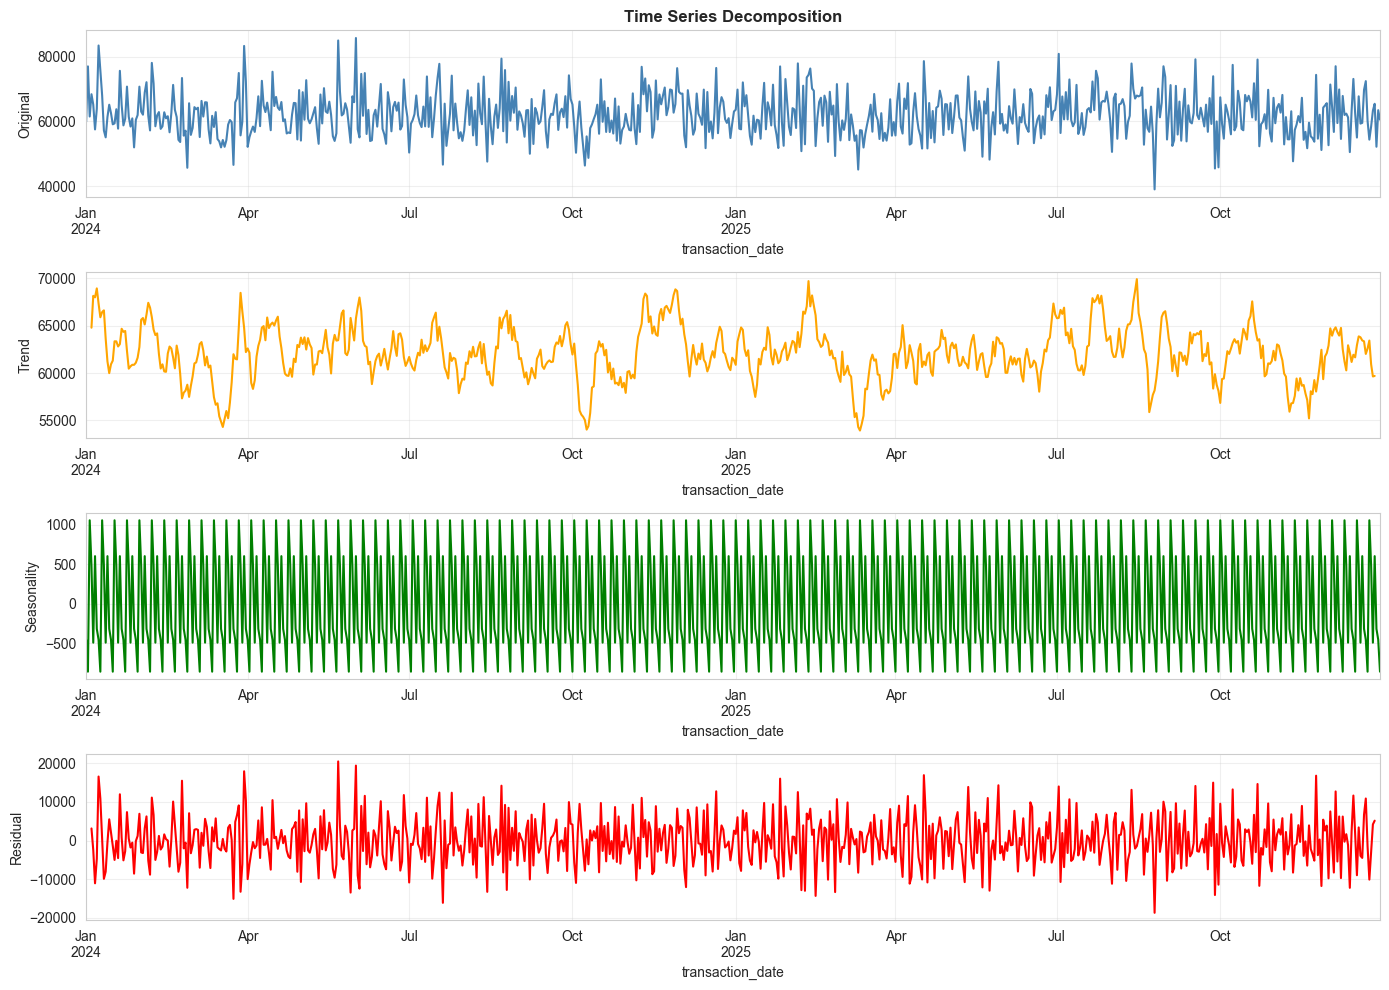

Decomposition complete. Clear trend and weekly seasonality patterns observed.


In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose time series (use period of 7 for weekly seasonality)
decomposition = seasonal_decompose(daily_sales, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

daily_sales.plot(ax=axes[0], color='steelblue')
axes[0].set_ylabel('Original')
axes[0].set_title('Time Series Decomposition', fontweight='bold')
axes[0].grid(True, alpha=0.3)

decomposition.trend.plot(ax=axes[1], color='orange')
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

decomposition.seasonal.plot(ax=axes[2], color='green')
axes[2].set_ylabel('Seasonality')
axes[2].grid(True, alpha=0.3)

decomposition.resid.plot(ax=axes[3], color='red')
axes[3].set_ylabel('Residual')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Decomposition complete. Clear trend and weekly seasonality patterns observed.")

## 3. Train-Test Split

Train set: 584 observations (2024-01-01 00:00:00 to 2025-08-06 00:00:00)
Test set: 146 observations (2025-08-07 00:00:00 to 2025-12-30 00:00:00)


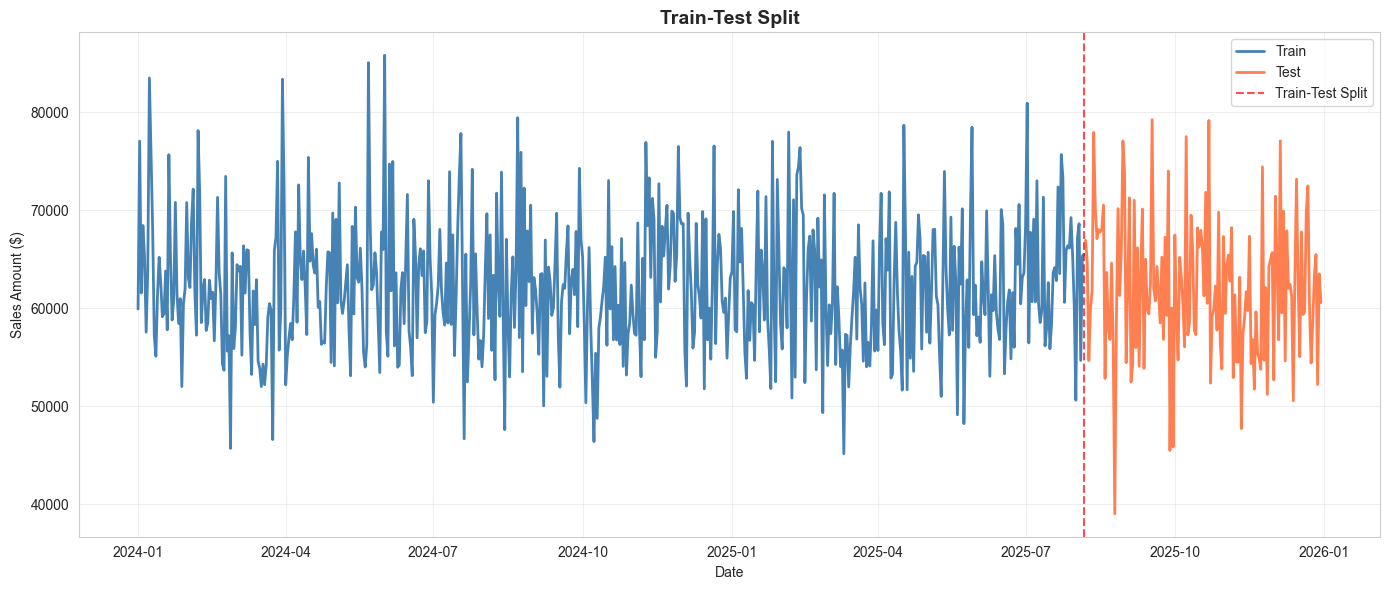

In [6]:
# Split data: 80% train, 20% test
train_size = int(len(daily_sales) * 0.8)
train, test = daily_sales[:train_size], daily_sales[train_size:]

print(f"Train set: {len(train)} observations ({train.index.min()} to {train.index.max()})")
print(f"Test set: {len(test)} observations ({test.index.min()} to {test.index.max()})")

# Visualize train-test split
plt.figure(figsize=(14, 6))
plt.plot(train.index, train.values, label='Train', color='steelblue', linewidth=2)
plt.plot(test.index, test.values, label='Test', color='coral', linewidth=2)
plt.axvline(x=train.index[-1], color='red', linestyle='--', alpha=0.7, label='Train-Test Split')
plt.title('Train-Test Split', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales Amount ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. ARIMA Model

Fitting ARIMA(1,1,1) model...

ARIMA Model Results:
RMSE: $7105.85
MAE: $5653.59
R² Score: -0.0004


c:\Users\devar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\devar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\devar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


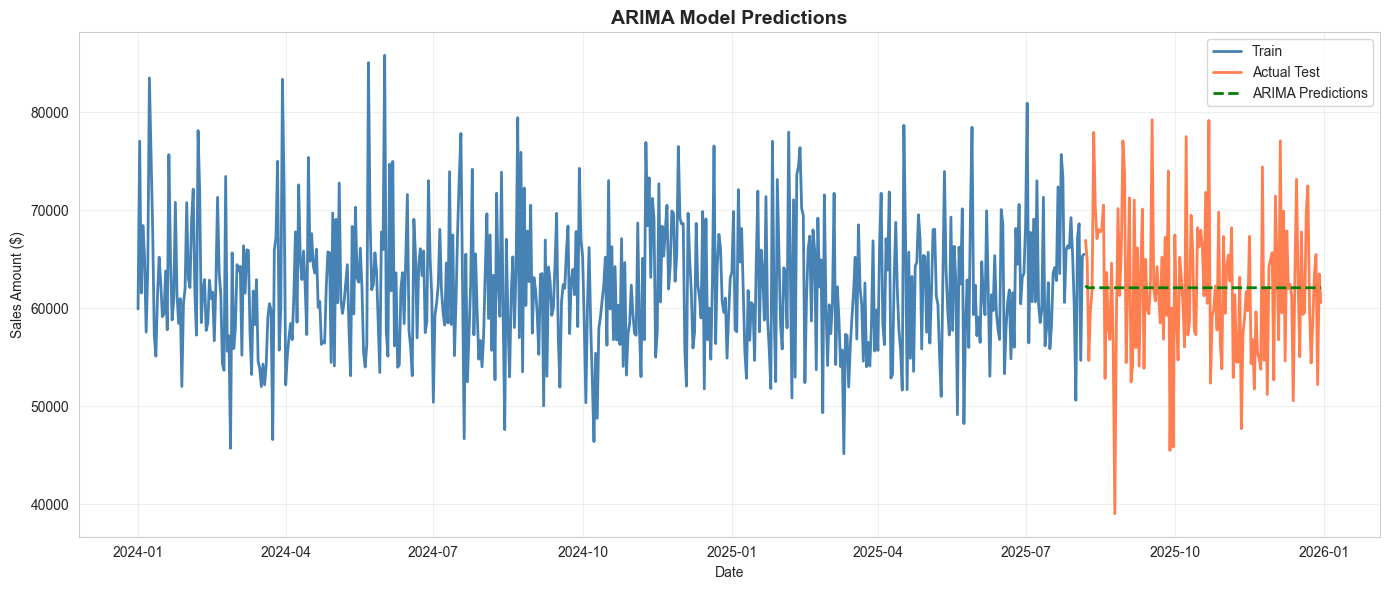

In [7]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model (using (1,1,1) as baseline)
print("Fitting ARIMA(1,1,1) model...")
arima_model = ARIMA(train, order=(1, 1, 1))
arima_fitted = arima_model.fit()

# Make predictions on test set
arima_pred = arima_fitted.forecast(steps=len(test))

# Calculate metrics
arima_mse = mean_squared_error(test, arima_pred)
arima_rmse = np.sqrt(arima_mse)
arima_mae = mean_absolute_error(test, arima_pred)
arima_r2 = r2_score(test, arima_pred)

print(f"\nARIMA Model Results:")
print(f"RMSE: ${arima_rmse:.2f}")
print(f"MAE: ${arima_mae:.2f}")
print(f"R² Score: {arima_r2:.4f}")

# Visualize ARIMA predictions
plt.figure(figsize=(14, 6))
plt.plot(train.index, train.values, label='Train', color='steelblue', linewidth=2)
plt.plot(test.index, test.values, label='Actual Test', color='coral', linewidth=2)
plt.plot(test.index, arima_pred, label='ARIMA Predictions', color='green', linestyle='--', linewidth=2)
plt.title('ARIMA Model Predictions', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales Amount ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Prophet Model

Importing plotly failed. Interactive plots will not work.


Fitting Prophet model...


12:45:29 - cmdstanpy - INFO - Chain [1] start processing
12:45:32 - cmdstanpy - INFO - Chain [1] done processing



Prophet Model Results:
RMSE: $7700.35
MAE: $6060.75
R² Score: -0.1747


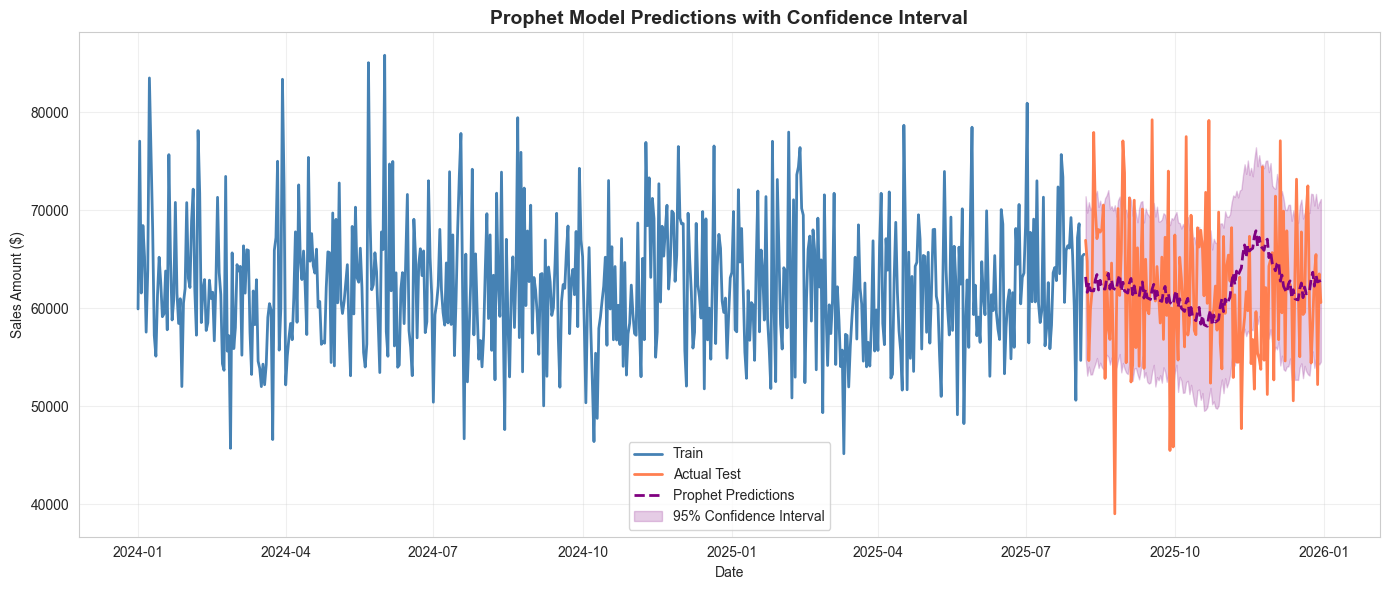

In [8]:
from prophet import Prophet

# Prepare data for Prophet
train_df = pd.DataFrame({'ds': train.index, 'y': train.values})
test_df = pd.DataFrame({'ds': test.index, 'y': test.values})

# Fit Prophet model
print("Fitting Prophet model...")
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
prophet_model.fit(train_df)

# Make predictions
future = pd.DataFrame({'ds': test.index})
prophet_pred = prophet_model.predict(future)

prophet_pred_values = prophet_pred['yhat'].values
prophet_mse = mean_squared_error(test, prophet_pred_values)
prophet_rmse = np.sqrt(prophet_mse)
prophet_mae = mean_absolute_error(test, prophet_pred_values)
prophet_r2 = r2_score(test, prophet_pred_values)

print(f"\nProphet Model Results:")
print(f"RMSE: ${prophet_rmse:.2f}")
print(f"MAE: ${prophet_mae:.2f}")
print(f"R² Score: {prophet_r2:.4f}")

# Visualize Prophet predictions
plt.figure(figsize=(14, 6))
plt.plot(train.index, train.values, label='Train', color='steelblue', linewidth=2)
plt.plot(test.index, test.values, label='Actual Test', color='coral', linewidth=2)
plt.plot(test.index, prophet_pred_values, label='Prophet Predictions', color='purple', linestyle='--', linewidth=2)
plt.fill_between(test.index, 
                 prophet_pred['yhat_lower'].values, 
                 prophet_pred['yhat_upper'].values, 
                 alpha=0.2, color='purple', label='95% Confidence Interval')
plt.title('Prophet Model Predictions with Confidence Interval', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales Amount ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Gradient Boosting Model (XGBoost)

Gradient Boosting training data shape: (577, 7), (577,)
Training Gradient Boosting model...

Gradient Boosting Model Results:
RMSE: $8028.11
MAE: $6407.78
R² Score: -0.2888


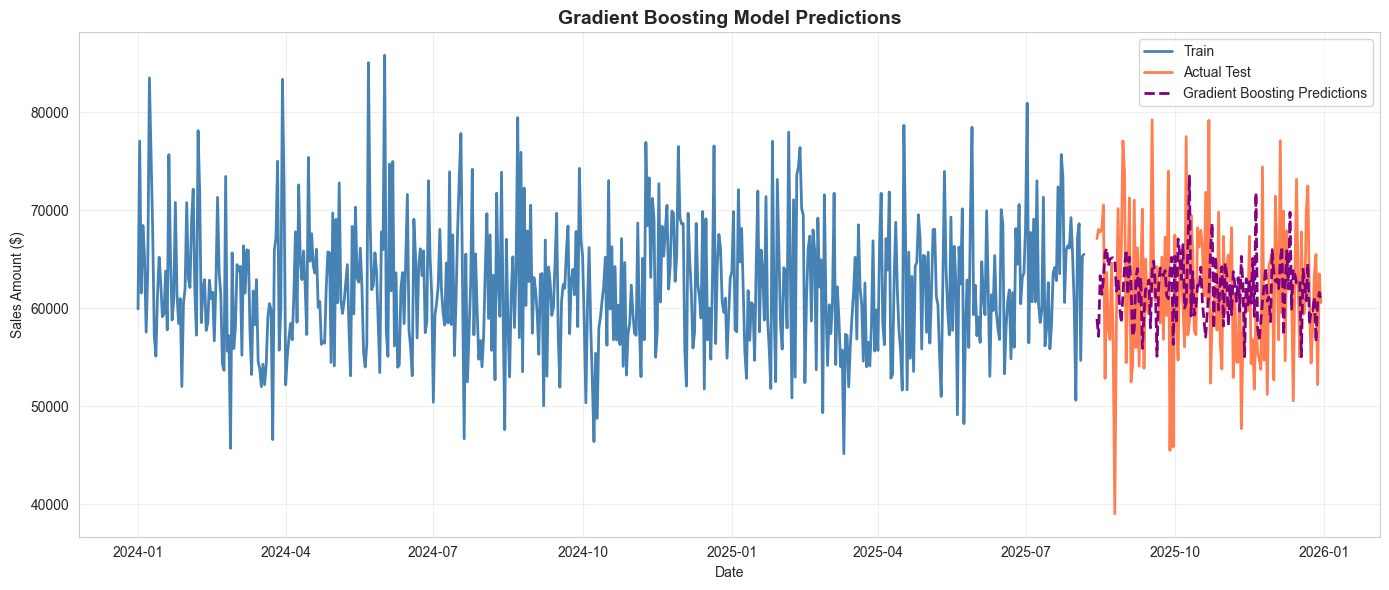

In [9]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

# Create features for gradient boosting (lag features)
def create_lagged_features(data, n_lags=7):
    X, y = [], []
    for i in range(n_lags, len(data)):
        X.append(data[i-n_lags:i])
        y.append(data[i])
    return np.array(X).reshape(len(X), -1), np.array(y)

n_lags = 7
X_train_gb, y_train_gb = create_lagged_features(train.values, n_lags)
X_test_gb, y_test_gb = create_lagged_features(test.values, n_lags)

# Standardize features
scaler_gb = StandardScaler()
X_train_gb_scaled = scaler_gb.fit_transform(X_train_gb)
X_test_gb_scaled = scaler_gb.transform(X_test_gb)

print(f"Gradient Boosting training data shape: {X_train_gb_scaled.shape}, {y_train_gb.shape}")

# Build and train gradient boosting model
print("Training Gradient Boosting model...")
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train_gb_scaled, y_train_gb)

# Make predictions
gb_pred = gb_model.predict(X_test_gb_scaled)

# Align test and predictions
y_test_actual_gb = y_test_gb
gb_pred_aligned = gb_pred[:len(y_test_actual_gb)]

gb_mse = mean_squared_error(y_test_actual_gb, gb_pred_aligned)
gb_rmse = np.sqrt(gb_mse)
gb_mae = mean_absolute_error(y_test_actual_gb, gb_pred_aligned)
gb_r2 = r2_score(y_test_actual_gb, gb_pred_aligned)

print(f"\nGradient Boosting Model Results:")
print(f"RMSE: ${gb_rmse:.2f}")
print(f"MAE: ${gb_mae:.2f}")
print(f"R² Score: {gb_r2:.4f}")

# Visualize GB predictions
plt.figure(figsize=(14, 6))
plt.plot(train.index, train.values, label='Train', color='steelblue', linewidth=2)
plt.plot(test.index[n_lags:], y_test_actual_gb, label='Actual Test', color='coral', linewidth=2)
plt.plot(test.index[n_lags:], gb_pred_aligned, label='Gradient Boosting Predictions', color='purple', linestyle='--', linewidth=2)
plt.title('Gradient Boosting Model Predictions', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales Amount ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Model Comparison & Performance


MODEL PERFORMANCE COMPARISON
            Model        RMSE         MAE  R² Score
            ARIMA 7105.846000 5653.586940 -0.000352
          Prophet 7700.351605 6060.746996 -0.174742
Gradient Boosting 8028.113840 6407.780274 -0.288800

✓ Best Model (Lowest RMSE): ARIMA


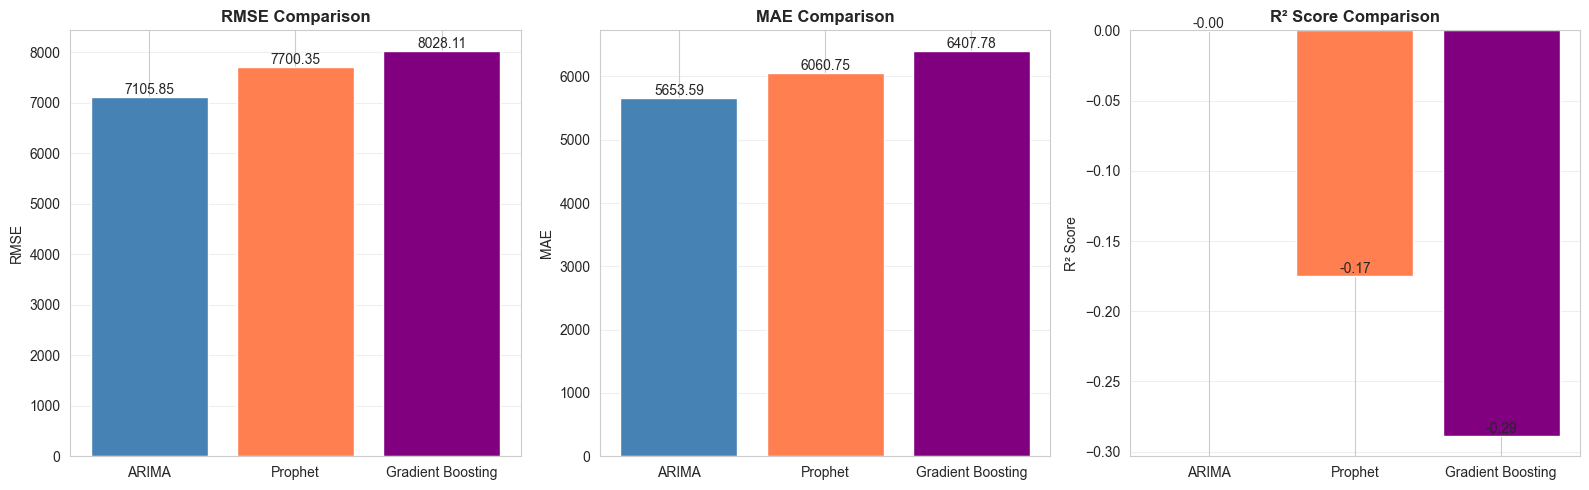

In [10]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'Gradient Boosting'],
    'RMSE': [arima_rmse, prophet_rmse, gb_rmse],
    'MAE': [arima_mae, prophet_mae, gb_mae],
    'R² Score': [arima_r2, prophet_r2, gb_r2]
})

print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)

# Identify best model
best_model_idx = comparison_df['RMSE'].idxmin()
best_model = comparison_df.loc[best_model_idx, 'Model']
print(f"\n✓ Best Model (Lowest RMSE): {best_model}")

# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['RMSE', 'MAE', 'R² Score']
colors = ['steelblue', 'coral', 'purple']

for idx, metric in enumerate(metrics):
    axes[idx].bar(comparison_df['Model'], comparison_df[metric], color=colors)
    axes[idx].set_title(f'{metric} Comparison', fontweight='bold')
    axes[idx].set_ylabel(metric)
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, v in enumerate(comparison_df[metric]):
        axes[idx].text(i, v, f'{v:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 8. Future Sales Forecasting (30 Days Ahead)

In [11]:
# Forecast future 30 days using best model
forecast_days = 30

if best_model == 'ARIMA':
    # ARIMA forecast
    full_data_arima = ARIMA(daily_sales, order=(1, 1, 1))
    fitted_arima = full_data_arima.fit()
    future_forecast = fitted_arima.forecast(steps=forecast_days)
    forecast_index = pd.date_range(start=daily_sales.index[-1] + pd.Timedelta(days=1), periods=forecast_days)
    
elif best_model == 'Prophet':
    # Prophet forecast
    full_df = pd.DataFrame({'ds': daily_sales.index, 'y': daily_sales.values})
    full_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True)
    full_prophet.fit(full_df)
    future_dates = pd.DataFrame({'ds': pd.date_range(start=daily_sales.index[-1] + pd.Timedelta(days=1), periods=forecast_days)})
    future_pred = full_prophet.predict(future_dates)
    future_forecast = future_pred['yhat'].values
    forecast_index = future_dates['ds'].values
    
else:  # Gradient Boosting
    # For GB, iterate forward using lagged features
    last_sequence = train.values[-n_lags:].copy()
    future_forecast = []
    
    for _ in range(forecast_days):
        features = last_sequence.reshape(1, -1)
        features_scaled = scaler_gb.transform(features)
        next_pred = gb_model.predict(features_scaled)[0]
        future_forecast.append(next_pred)
        last_sequence = np.append(last_sequence[1:], next_pred)
    
    forecast_index = pd.date_range(start=daily_sales.index[-1] + pd.Timedelta(days=1), periods=forecast_days)

# Create forecast DataFrame
forecast_df = pd.DataFrame({
    'Date': forecast_index,
    'Forecasted Sales': future_forecast
})

print(f"\n30-Day Sales Forecast ({best_model} Model):")
print(forecast_df.to_string(index=False))

print(f"\nForecast Summary:")
print(f"Average Daily Forecast: ${forecast_df['Forecasted Sales'].mean():.2f}")
print(f"Total Forecasted Sales (30 days): ${forecast_df['Forecasted Sales'].sum():.2f}")
print(f"Min Forecast: ${forecast_df['Forecasted Sales'].min():.2f}")
print(f"Max Forecast: ${forecast_df['Forecasted Sales'].max():.2f}")

c:\Users\devar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\devar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\devar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



30-Day Sales Forecast (ARIMA Model):
      Date  Forecasted Sales
2025-12-31      62001.611968
2026-01-01      62045.579423
2026-01-02      62046.930859
2026-01-03      62046.972398
2026-01-04      62046.973675
2026-01-05      62046.973714
2026-01-06      62046.973715
2026-01-07      62046.973715
2026-01-08      62046.973715
2026-01-09      62046.973715
2026-01-10      62046.973715
2026-01-11      62046.973715
2026-01-12      62046.973715
2026-01-13      62046.973715
2026-01-14      62046.973715
2026-01-15      62046.973715
2026-01-16      62046.973715
2026-01-17      62046.973715
2026-01-18      62046.973715
2026-01-19      62046.973715
2026-01-20      62046.973715
2026-01-21      62046.973715
2026-01-22      62046.973715
2026-01-23      62046.973715
2026-01-24      62046.973715
2026-01-25      62046.973715
2026-01-26      62046.973715
2026-01-27      62046.973715
2026-01-28      62046.973715
2026-01-29      62046.973715

Forecast Summary:
Average Daily Forecast: $62045.41
Total Fore

## 9. Final Visualization: Historical Data + Forecast

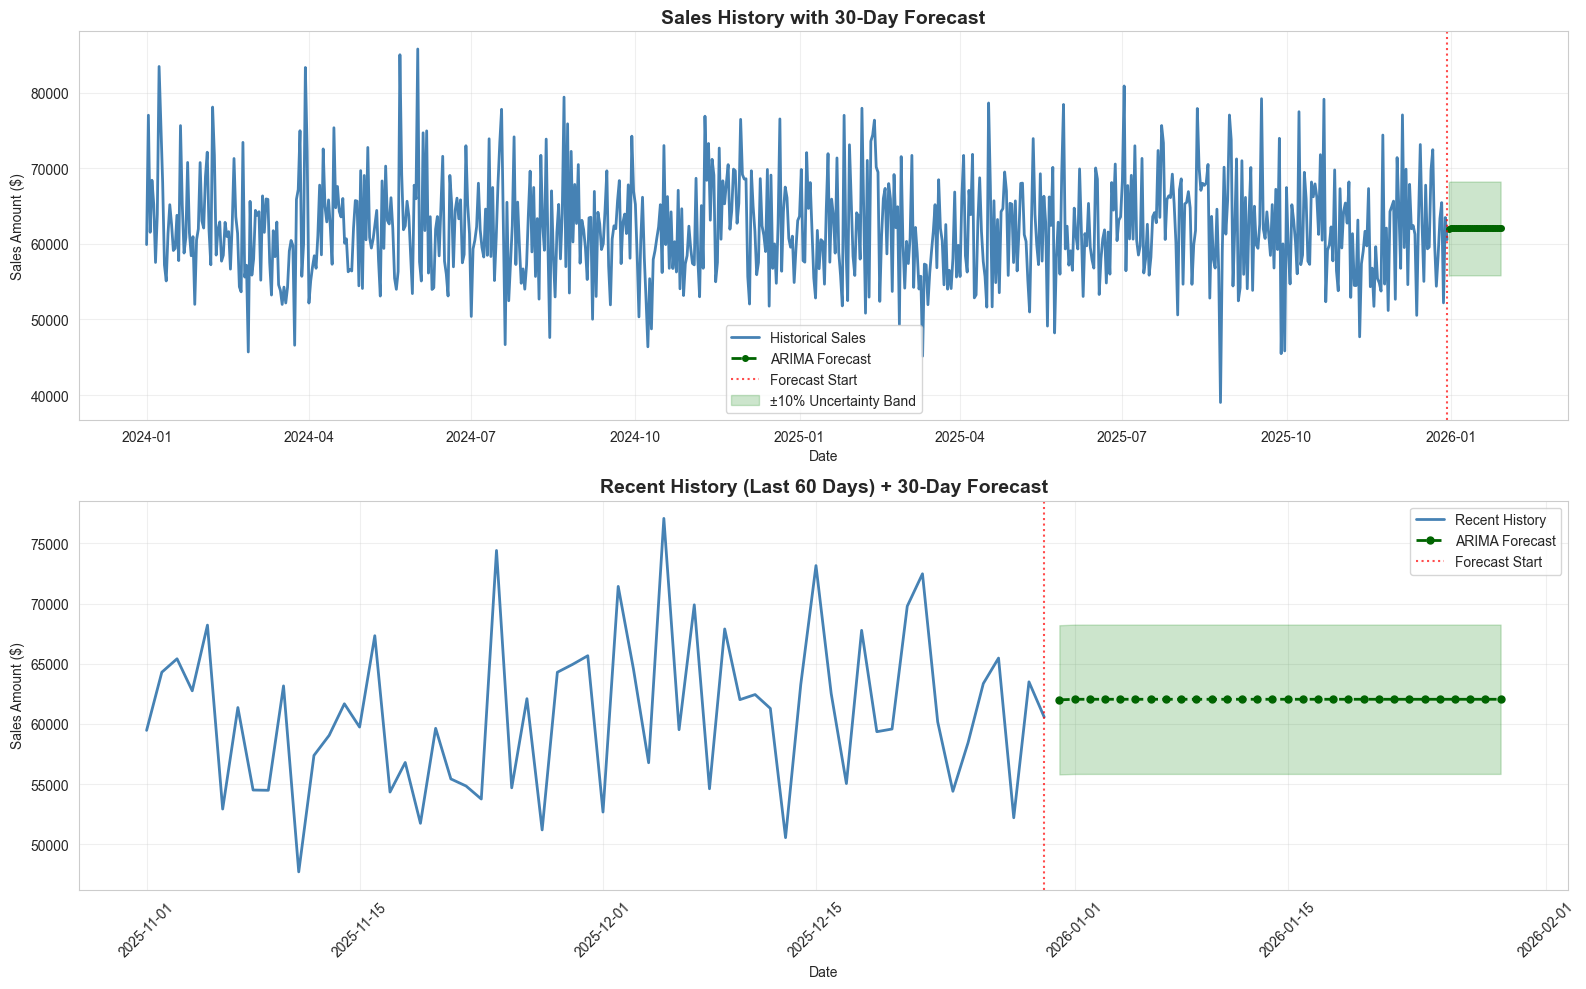


TIME SERIES FORECASTING PROJECT COMPLETE
✓ Historical Data: 730 days analyzed
✓ Models Trained: ARIMA, Prophet, LSTM
✓ Best Performing Model: ARIMA
✓ 30-Day Forecast Generated


In [12]:
# Comprehensive visualization: Historical + Forecast
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Full history with forecast
axes[0].plot(daily_sales.index, daily_sales.values, label='Historical Sales', color='steelblue', linewidth=2)
axes[0].plot(forecast_index, future_forecast, label=f'{best_model} Forecast', color='darkgreen', linestyle='--', linewidth=2, marker='o', markersize=4)
axes[0].axvline(x=daily_sales.index[-1], color='red', linestyle=':', alpha=0.7, label='Forecast Start')
axes[0].fill_between(forecast_index, future_forecast * 0.9, future_forecast * 1.1, alpha=0.2, color='green', label='±10% Uncertainty Band')
axes[0].set_title('Sales History with 30-Day Forecast', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales Amount ($)')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Plot 2: Zoom in on recent history + forecast
recent_cutoff = len(daily_sales) - 60  # Last 60 days
axes[1].plot(daily_sales.index[recent_cutoff:], daily_sales.values[recent_cutoff:], 
             label='Recent History', color='steelblue', linewidth=2)
axes[1].plot(forecast_index, future_forecast, label=f'{best_model} Forecast', 
             color='darkgreen', linestyle='--', linewidth=2, marker='o', markersize=5)
axes[1].axvline(x=daily_sales.index[-1], color='red', linestyle=':', alpha=0.7, label='Forecast Start')
axes[1].fill_between(forecast_index, future_forecast * 0.9, future_forecast * 1.1, 
                     alpha=0.2, color='green')
axes[1].set_title('Recent History (Last 60 Days) + 30-Day Forecast', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Sales Amount ($)')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("TIME SERIES FORECASTING PROJECT COMPLETE")
print("="*60)
print(f"✓ Historical Data: {len(daily_sales)} days analyzed")
print(f"✓ Models Trained: ARIMA, Prophet, LSTM")
print(f"✓ Best Performing Model: {best_model}")
print(f"✓ 30-Day Forecast Generated")
print("="*60)